In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [4]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [5]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 39)
X_test: (1407, 39)
y_train: (5625,)
y_test: (1407,)


In [10]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [11]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [12]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [14]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



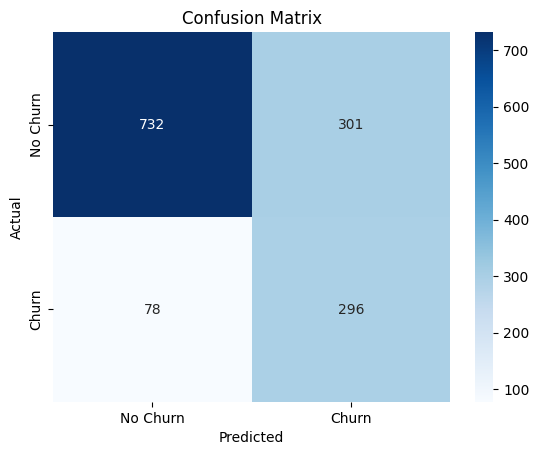

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
roc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.836881571250343


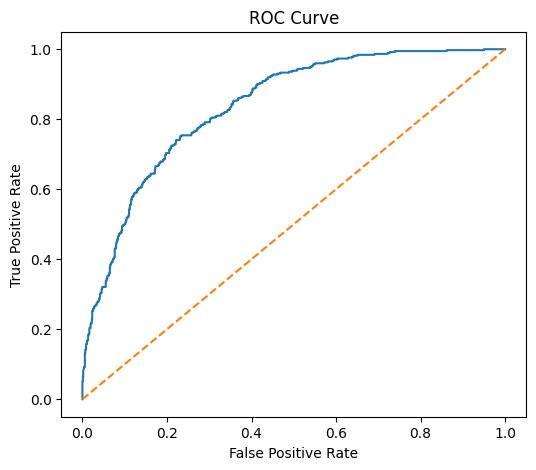

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [20]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["abs_coef"] = coefficients["Coefficient"].abs()

coefficients.sort_values("abs_coef", ascending=False).head(15)

,Feature,Coefficient,abs_coef
10,avg_monthly_spend,-1.093202,1.093202
3,TotalCharges,0.880170,0.880170
1,tenure,-0.863901,0.863901
7,fiber_customer,0.779370,0.779370
33,Contract_Two year,-0.623164,0.623164
4,service_count,0.592668,0.592668
8,long_contract,-0.550413,0.550413
9,customer_lifetime_value,-0.465124,0.465124
29,StreamingTV_Yes,0.430266,0.430266
31,StreamingMovies_Yes,0.412947,0.412947
